# Quadcopter Kinematic Simulation

In this notebook, we simulate a quadcopter kinematically. We prescribe the velocities directly without considering the vehicle dynamics or actuator limits.

**Mission profile:**
1. **Take-off**: Climb vertically from $0.5$ m to $5.0$ m.
2. **Cruise**: Fly North-East for $5.0$ m at the same altitude.
3. **Landing**: Descend vertically back to $0.5$ m altitude.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.simulation.video_sim import VideoSim
from src.utils.config import load_config

config_path = str(ROOT / "config/quadcopter_kinematic.yaml")
cfg = load_config(config_path)

In [ ]:
class QuadcopterKinematicSim(VideoSim):
    def __init__(self, config):
        super().__init__(config)
        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model needs a free root joint.")
            # Why do we need this? Because this is a way to make 
            # sure that MuJoCo understands that we're dealing with
            # a floating object, not attached by any means to the
            # world. 

        self.start_z = 0.5
        
        # Free joint states: [x, y, z, qw, qx, qy, qz]
        self.data.qpos[:7] = np.array([0.0, 0.0, self.start_z, 1.0, 0.0, 0.0, 0.0])
        self.data.qvel[:6] = 0.0

        # Own kinematic state tracking
        self._x = 0.0
        self._y = 0.0
        self._z = self.start_z
        self._yaw = 0.0

        # Camera settings
        cam_cfg = self.cfg.get('camera', {})
        self._cam_lookat   = np.array(cam_cfg.get('lookat',    [0.0, 0.0, 2.5]))
        self._cam_distance = float(cam_cfg.get('distance',  8.0))
        self._cam_elevation= float(cam_cfg.get('elevation', -30.0))
        self._cam_azimuth  = float(cam_cfg.get('azimuth',   45.0))

    def _capture_frame(self):
        # Update camera object dynamically
        self._camera.lookat[:] = self._cam_lookat
        self._camera.distance  = self._cam_distance
        self._camera.elevation = self._cam_elevation
        self._camera.azimuth   = self._cam_azimuth

        self._renderer.update_scene(
            self.data,
            camera=self._camera
        )

        pixels = self._renderer.render()
        self._frames.append(pixels)

    def _loop_step(self, t: float, step: int):
        dt = self.model.opt.timestep

        # ── 1. Plan velocities based on mission phase ──
        vx, vy, vz = 0.0, 0.0, 0.0
        
        # Takeoff phase: 0 to 5 seconds
        if t < 5.0:
            vz = 4.5 / 5.0  # Reach z = 5.0m from 0.5m
        
        # Horizontal phase (North-East): 5 to 10 seconds
        elif t < 10.0:
            # 5 meters total diagonal distance: v = 1 m/s
            v_xy = 5.0 / 5.0 
            vx = v_xy * np.cos(np.pi / 4)
            vy = v_xy * np.sin(np.pi / 4)
            
        # Landing phase: 10 to 15 seconds 
        elif t <= 15.0:
            vz = -4.5 / 5.0 # Return to z = 0.5m
        else:
            # Simulation usually ends at t_end = 15.0
            pass

        # ── 2. Update Kinematic State ──
        self._x += vx * dt
        self._y += vy * dt
        self._z += vz * dt
        
        if vx != 0.0 or vy != 0.0:
            self._yaw = np.arctan2(vy, vx)

        # ── 3. Write purely kinematic state back into MuJoCo ──
        self.data.qpos[0] = self._x
        self.data.qpos[1] = self._y
        self.data.qpos[2] = self._z
        
        qw = np.cos(self._yaw / 2.0)
        qz = np.sin(self._yaw / 2.0)
        self.data.qpos[3:7] = [qw, 0.0, 0.0, qz]  # Pure yaw rotation
        
        self.data.qvel[0] = vx
        self.data.qvel[1] = vy
        self.data.qvel[2] = vz
        self.data.qvel[3:6] = 0.0

        # Optional: track the quadcopter with the camera
        self._cam_lookat[:] = [self._x, self._y, self._z]

        # Read Euler angles from the MuJoCo quaternion stored in qpos[3:7]
        # qpos[3:7] = [qw, qx, qy, qz]
        qw, qx, qy, qz = self.data.qpos[3:7]
        # Quaternion -> Euler (roll, pitch, yaw), assuming scalar-first (w, x, y, z)
        t0 = 2.0 * (qw * qx + qy * qz)
        t1 = 1.0 - 2.0 * (qx * qx + qy * qy)
        roll = np.arctan2(t0, t1)

        t2 = 2.0 * (qw * qy - qz * qx)
        t2 = np.clip(t2, -1.0, 1.0)
        pitch = np.arcsin(t2)

        t3 = 2.0 * (qw * qz + qx * qy)
        t4 = 1.0 - 2.0 * (qy * qy + qz * qz)
        yaw = np.arctan2(t3, t4)

        # Keep internal yaw consistent with MuJoCo state
        self._yaw = float(yaw)

        self.logger.log({
            "t": t,
            "x": float(self._x),
            "y": float(self._y),
            "z": float(self._z),
            "vx": float(vx),
            "vy": float(vy),
            "vz": float(vz),
            "roll": float(roll),
            "pitch": float(pitch),
            "yaw": float(yaw)
        })

In [3]:
sim = QuadcopterKinematicSim(config_path)
sim.run()
df = sim.to_dataframe()
df.tail()

Simulation: 100%|██████████| 15000/15000 [00:03<00:00, 3975.72step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/quadcopter_kinematic.mp4


,t,x,y,z,vx,vy,vz,roll,pitch,yaw
14995,29.990,3.535534,3.535534,0.4982,0.0,0.0,0.0,0.0,0.0,0.785398
14996,29.992,3.535534,3.535534,0.4982,0.0,0.0,0.0,0.0,0.0,0.785398
14997,29.994,3.535534,3.535534,0.4982,0.0,0.0,0.0,0.0,0.0,0.785398
14998,29.996,3.535534,3.535534,0.4982,0.0,0.0,0.0,0.0,0.0,0.785398
14999,29.998,3.535534,3.535534,0.4982,0.0,0.0,0.0,0.0,0.0,0.785398


In [4]:
from IPython.display import Video, Image, display

video_path = Path(load_config(config_path)['video_path'])
if not video_path.is_absolute():
    video_path = ROOT / video_path

if video_path.exists():
    display(Video(str(video_path), embed=True))
else:
    frames_dir = video_path.parent / (video_path.stem + '_frames')
    if frames_dir.exists():
        pngs = sorted(frames_dir.glob('*.png'))
        if pngs:
            display(Image(str(pngs[-1])))
            print(f"MP4 not available. Showing last frame from {frames_dir}")

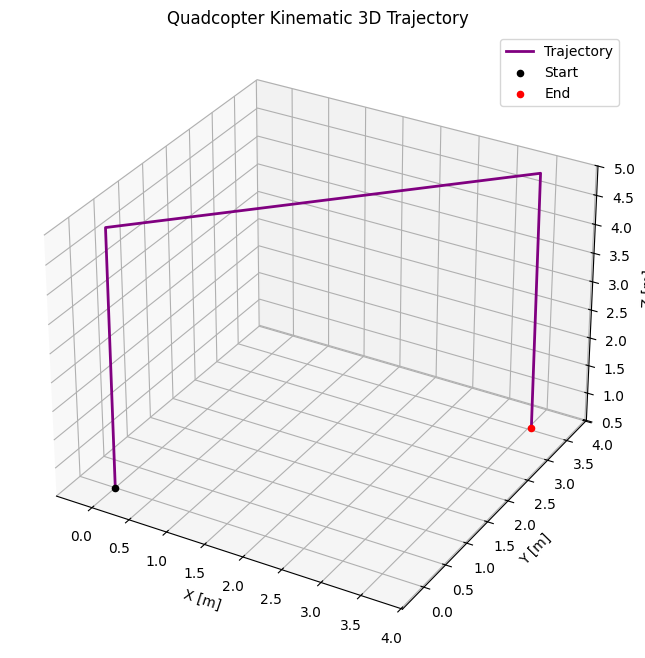

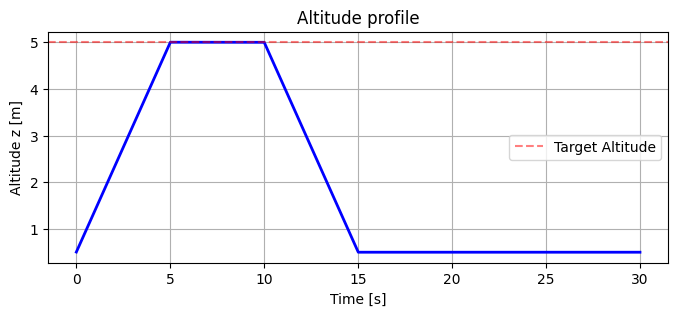

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D trajectory
ax.plot(df['x'], df['y'], df['z'], color='purple', linewidth=2, label='Trajectory')
ax.scatter([df['x'].iloc[0]], [df['y'].iloc[0]], [df['z'].iloc[0]], color='black', label='Start')
ax.scatter([df['x'].iloc[-1]], [df['y'].iloc[-1]], [df['z'].iloc[-1]], color='red', label='End')

# Set labels and title
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')
ax.set_title('Quadcopter Kinematic 3D Trajectory')

# Fix limits for equal aspect ratio logic visually
max_range = np.array([df['x'].max()-df['x'].min(), df['y'].max()-df['y'].min(), df['z'].max()-df['z'].min()]).max() / 2.0
mid_x = (df['x'].max()+df['x'].min()) * 0.5
mid_y = (df['y'].max()+df['y'].min()) * 0.5
mid_z = (df['z'].max()+df['z'].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.legend()
plt.show()

# Also show altitude vs time as a simple verification
plt.figure(figsize=(8, 3))
plt.plot(df['t'], df['z'], color='blue', linewidth=2)
plt.axhline(5.0, color='r', linestyle='--', alpha=0.5, label='Target Altitude')
plt.xlabel('Time [s]')
plt.ylabel('Altitude z [m]')
plt.title('Altitude profile')
plt.grid(True)
plt.legend()
plt.show()

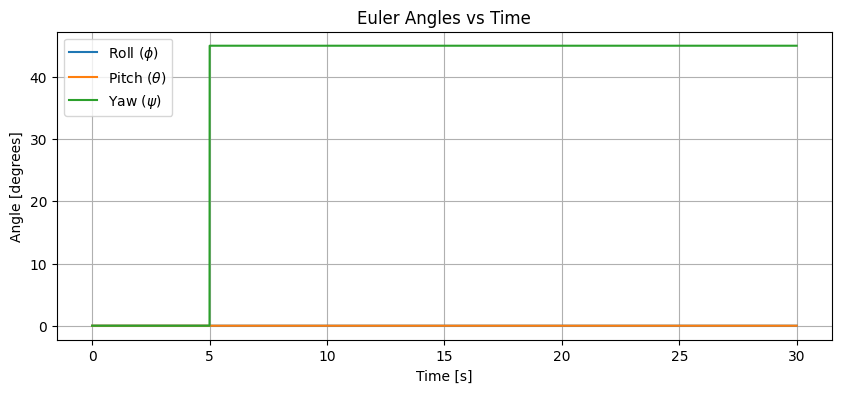

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(df['t'], np.degrees(df['roll']), label=r'Roll ($\phi$)')
plt.plot(df['t'], np.degrees(df['pitch']), label=r'Pitch ($\theta$)')
plt.plot(df['t'], np.degrees(df['yaw']), label=r'Yaw ($\psi$)')
plt.xlabel('Time [s]')
plt.ylabel('Angle [degrees]')
plt.title('Euler Angles vs Time')
plt.grid(True)
plt.legend()
plt.show()